# 04 — SVM Model
Train and evaluate a Support Vector Machine (SVM) classifier.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import os
import joblib

In [13]:
# --- Improve SVM with Scaling and Hyperparameter Tuning ---
import pandas as pd
df = pd.read_csv('../data/processed_dataset.csv')
X = df.drop('Health_Status', axis=1)
y = df['Health_Status']

In [15]:
# Scale features
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grid search for best parameters
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}
grid = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validated accuracy:", grid.best_score_)

# Evaluate on test set
y_pred = grid.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Save the best SVM model from GridSearchCV (scaled)
os.makedirs('../../models', exist_ok=True)
joblib.dump(grid.best_estimator_, '../../models/svm_model_scaled.pkl')
print('Best SVM scaled model saved as svm_model_scaled.pkl')

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validated accuracy: 0.8697916666666667
Test accuracy: 0.8166666666666667
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        60
           1       0.72      0.76      0.74        80
           2       0.88      0.88      0.88       100

    accuracy                           0.82       240
   macro avg       0.82      0.81      0.81       240
weighted avg       0.82      0.82      0.82       240

Best SVM scaled model saved as svm_model_scaled.pkl


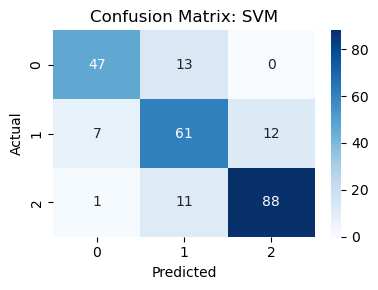

In [16]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: SVM')
plt.tight_layout()
plt.savefig('../../outputs/plots/confusion_matrix_svm.png')
plt.show()